In [1]:
# 05 - KNN Classifier on Breast Cancer Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score)

In [3]:
data = pd.read_csv('datasets/Breast_Cancer_Detection_Classification_Master.csv')
print("Shape:", data.shape)
print(data.head())
print()
print("Class distribution (B=benign, M=malignant):")
print(data['diagnosis'].value_counts())

Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimete

In [4]:
print("Null values (first 5):", data.isnull().sum().head().tolist())

Null values (first 5): [0, 0, 0, 0, 0]


In [5]:
X = data.drop(columns=['id', 'diagnosis']).values
y = data['diagnosis'].map({'B': 0, 'M': 1}).values

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (569, 30) y shape: (569,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (398, 30) Test: (171, 30)


In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Standardised.")

Standardised.


In [8]:
# K-sweep: K = 1, 2, 3, 4, 5

In [9]:
results = []
for k in [1, 2, 3, 4, 5]:
    model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append(acc)
    print("K =", k, ": accuracy =", acc)

print()
print("Accuracies:", results)

K = 1 : accuracy = 0.935672514619883
K = 2 : accuracy = 0.9415204678362573
K = 3 : accuracy = 0.935672514619883
K = 4 : accuracy = 0.9473684210526315
K = 5 : accuracy = 0.9590643274853801

Accuracies: [0.935672514619883, 0.9415204678362573, 0.935672514619883, 0.9473684210526315, 0.9590643274853801]


In [10]:
# Best model: K = 5

In [11]:
model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print("KNN [minkowski, K=5]")
print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_pred, y_test,
      target_names=['Benign', 'Malignant']))

KNN [minkowski, K=5]
Confusion Matrix:
[[107   1]
 [  6  57]]
Accuracy: 0.9590643274853801

              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97       113
   Malignant       0.90      0.98      0.94        58

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



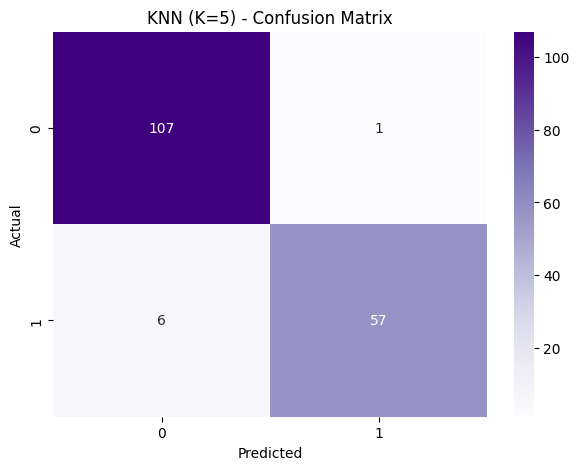

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN (K=5) - Confusion Matrix')
plt.show()

In [13]:
# Accuracy vs K plot

Best K = 9  accuracy = 0.9649122807017544


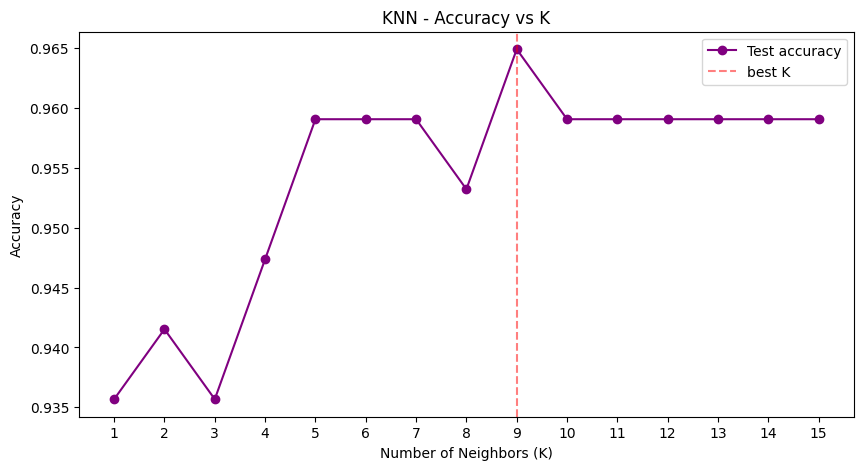

In [14]:
k_range = list(range(1, 16))
accs = []
for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    m.fit(X_train_scaled, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test_scaled)))

best_k = k_range[int(np.argmax(accs))]
print("Best K =", best_k, " accuracy =", max(accs))

plt.figure(figsize=(10, 5))
plt.plot(k_range, accs, 'o-', color='purple', label='Test accuracy')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.5, label='best K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN - Accuracy vs K')
plt.xticks(k_range)
plt.legend()
plt.show()